In [1]:
# ============================================================
# CELL 0: IMPORT ALL REQUIRED LIBRARIES
# ============================================================
# ✅ UPDATED: Added SMOTE, imblearn, GridSearchCV, TensorFlow
# ============================================================

import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

# Data splitting & validation
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV
)

# Preprocessing
from sklearn.preprocessing import (
    StandardScaler, OrdinalEncoder, OneHotEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score,
    matthews_corrcoef, precision_recall_curve, roc_curve
)

# SMOTE for oversampling ✅ NEW
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Outlier detection ✅ NEW
from scipy import stats

# Deep Learning ✅ NEW (optional)
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping
    HAS_TENSORFLOW = True
    print("✅ TensorFlow imported successfully")
except ImportError:
    HAS_TENSORFLOW = False
    print("⚠️  TensorFlow not available (optional)")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All Libraries Imported Successfully")

✅ TensorFlow imported successfully
✅ All Libraries Imported Successfully


In [2]:
# ============================================================
# CELL 1: LOAD AND EXPLORE DATASET
# ============================================================

# Load data
file_path = 'Student Depression Dataset - Cleaned.csv'
df = pd.read_csv(file_path)

# Basic info
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"\nShape: {df.shape}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# Column types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
missing = df.isnull().sum()
print(missing[missing > 0])

# Class distribution
print("\nTarget Class Distribution:")
print(df['Depression'].value_counts())
print("\nClass Balance (%):")
print(df['Depression'].value_counts(normalize=True).round(3) * 100)

# Preview
print("\nFirst 5 Rows:")
print(df.head())

DATASET OVERVIEW

Shape: (27901, 18)
Rows: 27901
Columns: 18

Data Types:
id                                         int64
Gender                                     int64
Age                                        int64
City                                      object
Profession                                object
Academic Pressure                          int64
Work Pressure                              int64
CGPA                                     float64
Study Satisfaction                         int64
Job Satisfaction                           int64
Sleep Duration                            object
Dietary Habits                            object
Degree                                    object
Have you ever had suicidal thoughts ?      int64
Work/Study Hours                           int64
Financial Stress                         float64
Family History of Mental Illness           int64
Depression                                 int64
dtype: object

Missing Values:
Financial Str

In [3]:
# ============================================================
# CELL 2: SMART OUTLIER REMOVAL (BALANCED APPROACH)
# ============================================================
# ✅ SMART: Removes only true outliers, preserves data integrity

print("\n" + "=" * 50)
print("SMART OUTLIER REMOVAL")
print("=" * 50)

initial_rows = len(df)
print(f"Starting with {initial_rows} rows...\n")

# Numeric columns
numeric_cols_for_outliers = [
    'Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
    'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours',
    'Financial Stress'
]

# Method: IQR (Interquartile Range) - More robust than Z-score
print("⏳ Detecting outliers using IQR method...\n")

outlier_mask = pd.Series([False] * len(df), index=df.index)

for col in numeric_cols_for_outliers:
    try:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Define outliers as beyond 3*IQR (very extreme)
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR

        col_outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
        n_col_outliers = col_outliers.sum()

        if n_col_outliers > 0:
            print(f"  ✓ {col:<25} : {n_col_outliers:>3} outliers beyond 3×IQR")

        outlier_mask = outlier_mask | col_outliers

    except Exception as e:
        print(f"  ⚠️  Skipping {col}: {e}")

n_outliers = outlier_mask.sum()

print(f"\n✅ Outlier Removal Summary:")
print(f"  Before: {initial_rows} rows")
print(f"  Found: {n_outliers} extreme outliers")

# Remove outliers
if n_outliers > 0 and initial_rows > 100:  # Safety check
    df = df[~outlier_mask].reset_index(drop=True)
    final_rows = len(df)
    removed_pct = (n_outliers / initial_rows * 100)

    print(f"  After: {final_rows} rows")
    print(f"  Removed: {n_outliers} rows ({removed_pct:.2f}%)")
else:
    print(f"  After: {initial_rows} rows")
    print(f"  No outliers removed")

# Verify data integrity
print(f"\n✅ Data Integrity Check:")
print(f"  Rows remaining: {len(df)} (Minimum required: 100)")

if len(df) < 100:
    print(f"\n  ⚠️  WARNING: Too few rows! Restoring original data...")
    print("      Outlier removal was too aggressive!")
    # This shouldn't happen with this method
else:
    print(f"  ✓ Data looks good!")

# Show distribution
print(f"\n✅ Depression Distribution:")
print(df['Depression'].value_counts())

print(f"\n✅ Dataset ready!")


SMART OUTLIER REMOVAL
Starting with 27901 rows...

⏳ Detecting outliers using IQR method...

  ✓ Age                       :   2 outliers beyond 3×IQR
  ✓ Work Pressure             :   3 outliers beyond 3×IQR
  ✓ Job Satisfaction          :   8 outliers beyond 3×IQR

✅ Outlier Removal Summary:
  Before: 27901 rows
  Found: 10 extreme outliers
  After: 27891 rows
  Removed: 10 rows (0.04%)

✅ Data Integrity Check:
  Rows remaining: 27891 (Minimum required: 100)
  ✓ Data looks good!

✅ Depression Distribution:
Depression
1    16332
0    11559
Name: count, dtype: int64

✅ Dataset ready!


In [4]:
# ============================================================
# CELL 3: DROP ID COLUMN (Not useful for prediction)
# ============================================================
# ✅ FIXED: Removed duplicate code

# 'id' is just a row identifier - not useful for prediction
if 'id' in df.columns:
    df = df.drop('id', axis=1)
    print("✅ 'id' column dropped")
else:
    print("ℹ️  'id' column not found (already dropped)")

print(f"New Shape: {df.shape}")
print(f"Remaining Columns: {df.columns.tolist()}")

✅ 'id' column dropped
New Shape: (27891, 17)
Remaining Columns: ['Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']


In [5]:
# ============================================================
# CELL 4: ADVANCED FEATURE ENGINEERING
# ============================================================
# ✅ UPDATED: Expanded from 4 to 16 engineered features (+2-5%)
# ============================================================

print("\n" + "=" * 70)
print("ADVANCED FEATURE ENGINEERING - 16 NEW FEATURES")
print("=" * 70)

# ── Feature 1: Total Pressure ──────────────────────────
# Academic + Work pressure combined = overall pressure
df['Total_Pressure'] = df['Academic Pressure'] + df['Work Pressure']

# ── Feature 2: Pressure to Satisfaction Ratio ──────────
# High pressure + Low satisfaction = depression risk
df['Pressure_Satisfaction_Ratio'] = (
    df['Total_Pressure'] /
    (df['Study Satisfaction'] + df['Job Satisfaction'] + 1)
)

# ── Feature 3: Sleep Deprivation Flag ──────────────────
# Less than 5 hours sleep = high risk
df['Sleep_Deprived'] = df['Sleep Duration'].apply(
    lambda x: 1 if x == 'Less than 5 hours' else 0
)

# ── Feature 4: Sleep Quality Score (0-3) ─────────────── ✅ NEW
# Granular sleep quality (not just binary)
# Optimal: 7-8 hours | Bad: Less than 5 | Too much: More than 8
sleep_mapping = {
    'Less than 5 hours': 0,      # Severe sleep deprivation
    '5-6 hours': 1,              # Mild sleep deprivation
    '7-8 hours': 3,              # Optimal
    'More than 8 hours': 2       # Oversleeping (also bad)
}
df['Sleep_Quality'] = df['Sleep Duration'].map(sleep_mapping)

# ── Feature 5: High Risk Flag ──────────────────────────
# Suicidal thoughts + High financial stress = very high risk
df['High_Risk'] = (
    (df['Have you ever had suicidal thoughts ?'] == 1) &
    (df['Financial Stress'] >= 4)
).astype(int)

# ── Feature 6: Stress Multiplier ─────────────────────── ✅ NEW
# Combines academic + work pressure non-linearly
# High multiplier = compounding effect
df['Stress_Multiplier'] = (
    df['Academic Pressure'] * df['Work Pressure']
)

# ── Feature 7: Overall Satisfaction Score (0-10) ────── ✅ NEW
# Combined satisfaction metric
df['Overall_Satisfaction'] = (
    df['Study Satisfaction'] + df['Job Satisfaction']
)

# ── Feature 8: Satisfaction-to-Pressure Ratio ──────── ✅ NEW
# Inverse of original ratio (different perspective)
df['Satisfaction_Pressure_Ratio'] = (
    (df['Study Satisfaction'] + df['Job Satisfaction'] + 1) /
    (df['Total_Pressure'] + 1)
)

# ── Feature 9: Work-Life Balance Index ────────────── ✅ NEW
# Low hours + High satisfaction = good balance
df['WorkLife_Balance'] = (
    df['Overall_Satisfaction'] / (df['Work/Study Hours'] + 1)
)

# ── Feature 10: Financial-Academic Stress Interaction ✅ NEW
# Interaction effect: both high = danger
df['FinAcad_Stress_Interaction'] = (
    df['Financial Stress'] * df['Academic Pressure']
)

# ── Feature 11: Suicidal Thought Severity ─────────── ✅ NEW
# Combine suicidal thoughts with other stressors
df['Suicide_Risk_Severity'] = (
    df['Have you ever had suicidal thoughts ?'] *
    (df['Financial Stress'] + df['Total_Pressure']) / 2
)

# ── Feature 12: Mental Health Vulnerability Score ─── ✅ NEW
# Weighted multi-factor risk assessment
df['MH_Vulnerability'] = (
    df['Have you ever had suicidal thoughts ?'] * 0.3 +
    (df['Financial Stress'] / 5) * 0.2 +
    (df['Total_Pressure'] / 5) * 0.2 +
    df['Sleep_Deprived'] * 0.15 +
    (1 - df['Overall_Satisfaction'] / 10) * 0.15
)

# ── Feature 13: CGPA Performance Gap ────────────────── ✅ NEW
# Low CGPA + High pressure = struggling student
df['CGPA_Performance_Gap'] = (
    (4.0 - df['CGPA']) * df['Academic Pressure']
)

# ── Feature 14: Perfect Health Indicator ──────────── ✅ NEW
# No risk factors = healthy
df['Perfect_Health'] = (
    (df['Have you ever had suicidal thoughts ?'] == 0) &
    (df['Financial Stress'] <= 2) &
    (df['Sleep_Deprived'] == 0) &
    (df['Total_Pressure'] <= 2)
).astype(int)

# ── Feature 15: Extreme Stress Indicator ───────────── ✅ NEW
# Multiple high stress factors simultaneously
df['Extreme_Stress'] = (
    ((df['Academic Pressure'] >= 4).astype(int) +
     (df['Financial Stress'] >= 4).astype(int) +
     (df['Work/Study Hours'] >= 10).astype(int) +
     df['Sleep_Deprived'] +
     (df['Overall_Satisfaction'] <= 3).astype(int))
    >= 3
).astype(int)

# ── Feature 16: CGPA Achievement ───────────────────── ✅ NEW
# How well student maintains grades despite pressure
df['CGPA_Achievement'] = (
    df['CGPA'] / (df['Academic Pressure'] + 1)
)

# Verify new features
print("\n✅ Advanced Features Created (16 total):")
new_features = [
    'Total_Pressure', 'Pressure_Satisfaction_Ratio', 'Sleep_Deprived',
    'Sleep_Quality', 'High_Risk', 'Stress_Multiplier', 'Overall_Satisfaction',
    'Satisfaction_Pressure_Ratio', 'WorkLife_Balance',
    'FinAcad_Stress_Interaction', 'Suicide_Risk_Severity',
    'MH_Vulnerability', 'CGPA_Performance_Gap', 'Perfect_Health',
    'Extreme_Stress', 'CGPA_Achievement'
]

print(f"Features: {new_features}")
print(f"\nFeature Statistics:")
stats_df = df[new_features].describe().round(2)
print(stats_df)

print(f"\nSample of New Features (first 10 rows):")
print(df[new_features].head(10))


ADVANCED FEATURE ENGINEERING - 16 NEW FEATURES

✅ Advanced Features Created (16 total):
Features: ['Total_Pressure', 'Pressure_Satisfaction_Ratio', 'Sleep_Deprived', 'Sleep_Quality', 'High_Risk', 'Stress_Multiplier', 'Overall_Satisfaction', 'Satisfaction_Pressure_Ratio', 'WorkLife_Balance', 'FinAcad_Stress_Interaction', 'Suicide_Risk_Severity', 'MH_Vulnerability', 'CGPA_Performance_Gap', 'Perfect_Health', 'Extreme_Stress', 'CGPA_Achievement']

Feature Statistics:
       Total_Pressure  Pressure_Satisfaction_Ratio  Sleep_Deprived  \
count        27891.00                     27891.00        27891.00   
mean             3.14                         0.93            0.30   
std              1.38                         0.61            0.46   
min              0.00                         0.00            0.00   
25%              2.00                         0.50            0.00   
50%              3.00                         0.80            0.00   
75%              4.00                    

In [6]:
# ============================================================
# CELL 5: PREPARE FEATURES AND TARGET
# ============================================================

# Target variable
X = df.drop('Depression', axis=1)
y = df['Depression']

print("✅ Features (X) and Target (y) prepared")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nTarget Distribution:")
print(y.value_counts())

✅ Features (X) and Target (y) prepared
X shape: (27891, 32)
y shape: (27891,)

Target Distribution:
Depression
1    16332
0    11559
Name: count, dtype: int64


In [7]:
# ============================================================
# CELL 6: CATEGORIZE FEATURES BY TYPE
# ============================================================

# ── Ordinal: has meaningful order ──────────────────────
# Less than 5 < 5-6 < 7-8 < More than 8
ordinal_cols = ['Sleep Duration']
sleep_order = [[
    'Less than 5 hours',
    '5-6 hours',
    '7-8 hours',
    'More than 8 hours'
]]

# ── Nominal: no meaningful order ───────────────────────
nominal_cols = ['City', 'Profession', 'Dietary Habits', 'Degree']

# ── Numerical: already numbers ─────────────────────────
numerical_cols = [
    col for col in X.columns
    if col not in ordinal_cols + nominal_cols
]

# Verify
print("✅ Feature Groups Defined")
print(f"\nNumerical ({len(numerical_cols)}):")
print(numerical_cols)
print(f"\nOrdinal ({len(ordinal_cols)}):")
print(ordinal_cols)
print(f"\nNominal ({len(nominal_cols)}):")
print(nominal_cols)
print(f"\nTotal Features: {len(numerical_cols) + len(ordinal_cols) + len(nominal_cols)}")

✅ Feature Groups Defined

Numerical (27):
['Gender', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Total_Pressure', 'Pressure_Satisfaction_Ratio', 'Sleep_Deprived', 'Sleep_Quality', 'High_Risk', 'Stress_Multiplier', 'Overall_Satisfaction', 'Satisfaction_Pressure_Ratio', 'WorkLife_Balance', 'FinAcad_Stress_Interaction', 'Suicide_Risk_Severity', 'MH_Vulnerability', 'CGPA_Performance_Gap', 'Perfect_Health', 'Extreme_Stress', 'CGPA_Achievement']

Ordinal (1):
['Sleep Duration']

Nominal (4):
['City', 'Profession', 'Dietary Habits', 'Degree']

Total Features: 32


In [8]:
# ============================================================
# CELL 7: BUILD PREPROCESSING PIPELINES
# ============================================================

# ── Numerical Pipeline ─────────────────────────────────
# Step 1: Impute with median (robust to outliers)
# Step 2: Scale to 0-1 range (StandardScaler)
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# ── Ordinal Pipeline ───────────────────────────────────
# Step 1: Impute with most frequent value
# Step 2: Encode preserving order (Less than 5 < 5-6 < 7-8 < More than 8)
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(
        categories=sleep_order,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

# ── Nominal Pipeline ───────────────────────────────────
# Step 1: Impute with most frequent value
# Step 2: One-hot encode (convert to binary columns)
nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False,
        max_categories=20
    ))
])

# ── Combine All ────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('ord', ordinal_transformer, ordinal_cols),
    ('nom', nominal_transformer, nominal_cols)
])

print("✅ Preprocessing Pipelines Built")
print("""
Pipeline Summary:
┌─────────────┬────────────────────────────────────┐
│ Feature Type│ Steps                              │
├─────────────┼────────────────────────────────────┤
│ Numerical   │ Median Impute → StandardScaler     │
│ Ordinal     │ Mode Impute → OrdinalEncoder       │
│ Nominal     │ Mode Impute → OneHotEncoder        │
└─────────────┴────────────────────────────────────┘
""")

✅ Preprocessing Pipelines Built

Pipeline Summary:
┌─────────────┬────────────────────────────────────┐
│ Feature Type│ Steps                              │
├─────────────┼────────────────────────────────────┤
│ Numerical   │ Median Impute → StandardScaler     │
│ Ordinal     │ Mode Impute → OrdinalEncoder       │
│ Nominal     │ Mode Impute → OneHotEncoder        │
└─────────────┴────────────────────────────────────┘



In [9]:
# ============================================================
# CELL 8: SPLIT DATA INTO TRAIN/TEST WITH STRATIFICATION
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # ← KEY: keeps class ratio in both splits
)

print("✅ Data Split Complete")
print(f"\nTraining Set: {X_train.shape}")
print(f"Testing Set: {X_test.shape}")

print("\nClass Balance in Training Set:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True).round(3) * 100)

print("\nClass Balance in Testing Set:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True).round(3) * 100)

✅ Data Split Complete

Training Set: (22312, 32)
Testing Set: (5579, 32)

Class Balance in Training Set:
Depression
1    13065
0     9247
Name: count, dtype: int64
Depression
1    58.6
0    41.4
Name: proportion, dtype: float64

Class Balance in Testing Set:
Depression
1    3267
0    2312
Name: count, dtype: int64
Depression
1    58.6
0    41.4
Name: proportion, dtype: float64


In [10]:
# ============================================================
# CELL 9: CALCULATE IMBALANCE RATIO FOR XGBoost
# ============================================================
# ✅ UPDATED: Used for class weighting in XGBoost

# Calculate ratio for XGBoost scale_pos_weight
neg_count = len(y_train[y_train == 0])
pos_count = len(y_train[y_train == 1])
imbalance_ratio = neg_count / pos_count

print("✅ Imbalance Ratio Calculated:")
print(f"Non-depressed (0): {neg_count}")
print(f"Depressed (1): {pos_count}")
print(f"Ratio: {imbalance_ratio:.3f}")
print(f"\nMeaning: For every {imbalance_ratio:.2f} non-depressed students,")
print(f"there is 1 depressed student")

✅ Imbalance Ratio Calculated:
Non-depressed (0): 9247
Depressed (1): 13065
Ratio: 0.708

Meaning: For every 0.71 non-depressed students,
there is 1 depressed student


In [11]:
# ============================================================
# CELL 10: HYPERPARAMETER TUNING WITH GRIDSEARCHCV
# ============================================================
# ✅ FIXED: Added missing imports at the top of the cell
# ⏱️  WARNING: This cell takes 10-15 minutes to run!
# ============================================================

# ✅ IMPORT FIX: Add these imports if not already in CELL 0
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print("\n" + "=" * 70)
print("HYPERPARAMETER TUNING WITH GRIDSEARCHCV")
print("=" * 70)
print("⏳ This will take 10-15 minutes. Grab a coffee! ☕\n")

# ── Logistic Regression Tuning ──────────────────────
print("🔄 [1/3] Tuning Logistic Regression...")
print("   Testing 15 parameter combinations with 5-fold CV...")

lr_params = {
    'classifier__C': [0.1, 0.5, 1.0, 2.0, 5.0],
    'classifier__max_iter': [1000, 2000, 3000],
}

lr_grid = GridSearchCV(
    Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            class_weight='balanced',
            solver='lbfgs',
            random_state=42
        ))
    ]),
    lr_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

try:
    lr_grid.fit(X_train, y_train)
    print(f"   ✅ Best LR params: {lr_grid.best_params_}")
    print(f"      Best CV AUC: {lr_grid.best_score_:.4f}\n")
except Exception as e:
    print(f"   ⚠️  Error in LR tuning: {e}\n")
    lr_grid = None

# ── Random Forest Tuning ────────────────────────────
print("🔄 [2/3] Tuning Random Forest...")
print("   Testing 48 parameter combinations with 5-fold CV...")

rf_params = {
    'classifier__n_estimators': [200, 300, 400],
    'classifier__max_depth': [12, 15, 18],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
}

rf_grid = GridSearchCV(
    Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]),
    rf_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

try:
    rf_grid.fit(X_train, y_train)
    print(f"   ✅ Best RF params: {rf_grid.best_params_}")
    print(f"      Best CV AUC: {rf_grid.best_score_:.4f}\n")
except Exception as e:
    print(f"   ⚠️  Error in RF tuning: {e}\n")
    rf_grid = None

# ── XGBoost Tuning ──────────────────────────────────
print("🔄 [3/3] Tuning XGBoost...")
print("   Testing 36 parameter combinations with 5-fold CV...")

xgb_params = {
    'classifier__n_estimators': [200, 300, 400],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [4, 5, 6],
    'classifier__subsample': [0.7, 0.8],
}

xgb_grid = GridSearchCV(
    Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(
            scale_pos_weight=imbalance_ratio,
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1,
            verbosity=0  # Suppress XGBoost verbose output
        ))
    ]),
    xgb_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

try:
    xgb_grid.fit(X_train, y_train)
    print(f"   ✅ Best XGB params: {xgb_grid.best_params_}")
    print(f"      Best CV AUC: {xgb_grid.best_score_:.4f}\n")
except Exception as e:
    print(f"   ⚠️  Error in XGB tuning: {e}\n")
    xgb_grid = None

# Store best estimators for later use
print("=" * 70)
print("SAVING BEST MODELS")
print("=" * 70)

# Check if gridsearch was successful before storing
if lr_grid is not None:
    best_lr_model = lr_grid.best_estimator_
    print(f"✅ Best LR model saved")
else:
    print(f"⚠️  Using default LR model (tuning failed)")
    best_lr_model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            C=1.0, max_iter=2000, class_weight='balanced',
            solver='lbfgs', random_state=42
        ))
    ])

if rf_grid is not None:
    best_rf_model = rf_grid.best_estimator_
    print(f"✅ Best RF model saved")
else:
    print(f"⚠️  Using default RF model (tuning failed)")
    best_rf_model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=300, max_depth=15, class_weight='balanced',
            random_state=42, n_jobs=-1
        ))
    ])

if xgb_grid is not None:
    best_xgb_model = xgb_grid.best_estimator_
    print(f"✅ Best XGB model saved")
else:
    print(f"⚠️  Using default XGB model (tuning failed)")
    best_xgb_model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=6,
            scale_pos_weight=imbalance_ratio, eval_metric='logloss',
            random_state=42, n_jobs=-1
        ))
    ])

print("\n" + "=" * 70)
print("✅ GRIDSEARCH TUNING COMPLETE")
print("=" * 70)
print(f"\n✅ All best models ready for training!")


HYPERPARAMETER TUNING WITH GRIDSEARCHCV
⏳ This will take 10-15 minutes. Grab a coffee! ☕

🔄 [1/3] Tuning Logistic Regression...
   Testing 15 parameter combinations with 5-fold CV...
   ✅ Best LR params: {'classifier__C': 0.1, 'classifier__max_iter': 1000}
      Best CV AUC: 0.9206

🔄 [2/3] Tuning Random Forest...
   Testing 48 parameter combinations with 5-fold CV...
   ✅ Best RF params: {'classifier__max_depth': 12, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 400}
      Best CV AUC: 0.9152

🔄 [3/3] Tuning XGBoost...
   Testing 36 parameter combinations with 5-fold CV...
   ✅ Best XGB params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 4, 'classifier__n_estimators': 200, 'classifier__subsample': 0.7}
      Best CV AUC: 0.9200

SAVING BEST MODELS
✅ Best LR model saved
✅ Best RF model saved
✅ Best XGB model saved

✅ GRIDSEARCH TUNING COMPLETE

✅ All best models ready for training!


In [12]:
# ============================================================
# CELL 11: LOGISTIC REGRESSION (WITH BEST PARAMS)
# ============================================================
# ✅ UPDATED: Uses GridSearch best parameters

print("\n" + "=" * 70)
print("LOGISTIC REGRESSION (OPTIMIZED)")
print("=" * 70)

# Use best model from GridSearchCV
lr_model = best_lr_model

# Train
print("⏳ Training Logistic Regression...")
lr_model.fit(X_train, y_train)

# Predict
lr_pred = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

# Evaluate
print("\n✅ Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, lr_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, lr_proba):.4f}")
print(f"Precision: {precision_score(y_test, lr_pred):.4f}")
print(f"Recall: {recall_score(y_test, lr_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred,
    target_names=['No Depression', 'Depression']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, lr_pred))


LOGISTIC REGRESSION (OPTIMIZED)
⏳ Training Logistic Regression...

✅ Logistic Regression Results:
Accuracy: 0.8464
F1 Score: 0.8661
AUC-ROC: 0.9243
Precision: 0.8845
Recall: 0.8485

Classification Report:
               precision    recall  f1-score   support

No Depression       0.80      0.84      0.82      2312
   Depression       0.88      0.85      0.87      3267

     accuracy                           0.85      5579
    macro avg       0.84      0.85      0.84      5579
 weighted avg       0.85      0.85      0.85      5579

Confusion Matrix:
[[1950  362]
 [ 495 2772]]


In [13]:
# ============================================================
# CELL 12: RANDOM FOREST (WITH BEST PARAMS)
# ============================================================
# ✅ UPDATED: Uses GridSearch best parameters

print("\n" + "=" * 70)
print("RANDOM FOREST (OPTIMIZED)")
print("=" * 70)

# Use best model from GridSearchCV
rf_model = best_rf_model

# Train
print("⏳ Training Random Forest...")
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluate
print("\n✅ Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, rf_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, rf_proba):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"Recall: {recall_score(y_test, rf_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred,
    target_names=['No Depression', 'Depression']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))


RANDOM FOREST (OPTIMIZED)
⏳ Training Random Forest...

✅ Random Forest Results:
Accuracy: 0.8408
F1 Score: 0.8628
AUC-ROC: 0.9188
Precision: 0.8709
Recall: 0.8549

Classification Report:
               precision    recall  f1-score   support

No Depression       0.80      0.82      0.81      2312
   Depression       0.87      0.85      0.86      3267

     accuracy                           0.84      5579
    macro avg       0.84      0.84      0.84      5579
 weighted avg       0.84      0.84      0.84      5579

Confusion Matrix:
[[1898  414]
 [ 474 2793]]


In [14]:
# ============================================================
# CELL 13: XGBOOST (WITH BEST PARAMS)
# ============================================================
# ✅ UPDATED: Uses GridSearch best parameters

print("\n" + "=" * 70)
print("XGBOOST (OPTIMIZED)")
print("=" * 70)

# Use best model from GridSearchCV
xgb_model = best_xgb_model

# Train
print("⏳ Training XGBoost...")
xgb_model.fit(X_train, y_train)

# Predict
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate
print("\n✅ XGBoost Results:")
print(f"Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, xgb_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, xgb_proba):.4f}")
print(f"Precision: {precision_score(y_test, xgb_pred):.4f}")
print(f"Recall: {recall_score(y_test, xgb_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred,
    target_names=['No Depression', 'Depression']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))


XGBOOST (OPTIMIZED)
⏳ Training XGBoost...

✅ XGBoost Results:
Accuracy: 0.8464
F1 Score: 0.8659
AUC-ROC: 0.9237
Precision: 0.8855
Recall: 0.8473

Classification Report:
               precision    recall  f1-score   support

No Depression       0.80      0.85      0.82      2312
   Depression       0.89      0.85      0.87      3267

     accuracy                           0.85      5579
    macro avg       0.84      0.85      0.84      5579
 weighted avg       0.85      0.85      0.85      5579

Confusion Matrix:
[[1954  358]
 [ 499 2768]]


In [15]:
# ============================================================
# CELL 14: GRADIENT BOOSTING CLASSIFIER
# ============================================================
# ✅ NEW CELL: 4th ensemble member (+1-2%)

print("\n" + "=" * 70)
print("GRADIENT BOOSTING CLASSIFIER")
print("=" * 70)

gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        subsample=0.8,
        random_state=42
    ))
])

# Train
print("⏳ Training Gradient Boosting...")
gb_model.fit(X_train, y_train)

# Predict
gb_pred = gb_model.predict(X_test)
gb_proba = gb_model.predict_proba(X_test)[:, 1]

# Evaluate
print("\n✅ Gradient Boosting Results:")
print(f"Accuracy: {accuracy_score(y_test, gb_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, gb_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, gb_proba):.4f}")
print(f"Precision: {precision_score(y_test, gb_pred):.4f}")
print(f"Recall: {recall_score(y_test, gb_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, gb_pred,
    target_names=['No Depression', 'Depression']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, gb_pred))


GRADIENT BOOSTING CLASSIFIER
⏳ Training Gradient Boosting...

✅ Gradient Boosting Results:
Accuracy: 0.8464
F1 Score: 0.8704
AUC-ROC: 0.9219
Precision: 0.8599
Recall: 0.8812

Classification Report:
               precision    recall  f1-score   support

No Depression       0.83      0.80      0.81      2312
   Depression       0.86      0.88      0.87      3267

     accuracy                           0.85      5579
    macro avg       0.84      0.84      0.84      5579
 weighted avg       0.85      0.85      0.85      5579

Confusion Matrix:
[[1843  469]
 [ 388 2879]]


In [16]:
# ============================================================
# CELL 15: WEIGHTED VOTING ENSEMBLE
# ============================================================
# ✅ UPDATED: Uses best models + Gradient Boosting + weights

print("\n" + "=" * 70)
print("WEIGHTED VOTING ENSEMBLE (4 MODELS)")
print("=" * 70)

ensemble_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(
                C=lr_grid.best_params_['classifier__C'],
                max_iter=lr_grid.best_params_['classifier__max_iter'],
                class_weight='balanced',
                solver='lbfgs',
                random_state=42
            )),
            ('rf', RandomForestClassifier(
                n_estimators=rf_grid.best_params_['classifier__n_estimators'],
                max_depth=rf_grid.best_params_['classifier__max_depth'],
                min_samples_split=rf_grid.best_params_['classifier__min_samples_split'],
                min_samples_leaf=rf_grid.best_params_['classifier__min_samples_leaf'],
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )),
            ('xgb', XGBClassifier(
                n_estimators=xgb_grid.best_params_['classifier__n_estimators'],
                learning_rate=xgb_grid.best_params_['classifier__learning_rate'],
                max_depth=xgb_grid.best_params_['classifier__max_depth'],
                subsample=xgb_grid.best_params_['classifier__subsample'],
                scale_pos_weight=imbalance_ratio,
                eval_metric='logloss',
                random_state=42,
                n_jobs=-1
            )),
            ('gb', GradientBoostingClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=5,
                random_state=42
            ))
        ],
        voting='soft',
        weights=[1, 2, 2, 1.5]  # Weighted voting: XGB & RF stronger
    ))
])

# Train
print("⏳ Training Weighted Ensemble...")
ensemble_model.fit(X_train, y_train)

# Predict
ens_pred = ensemble_model.predict(X_test)
ens_proba = ensemble_model.predict_proba(X_test)[:, 1]

# Evaluate
print("\n✅ Weighted Ensemble Results:")
ens_acc = accuracy_score(y_test, ens_pred)
ens_f1 = f1_score(y_test, ens_pred)
ens_auc = roc_auc_score(y_test, ens_proba)
ens_prec = precision_score(y_test, ens_pred)
ens_rec = recall_score(y_test, ens_pred)

print(f"Accuracy: {ens_acc:.4f} ← PRIMARY METRIC")
print(f"F1 Score: {ens_f1:.4f}")
print(f"AUC-ROC: {ens_auc:.4f} ← BEST FOR IMBALANCED DATA")
print(f"Precision: {ens_prec:.4f}")
print(f"Recall: {ens_rec:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, ens_pred,
    target_names=['No Depression', 'Depression']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, ens_pred))


WEIGHTED VOTING ENSEMBLE (4 MODELS)
⏳ Training Weighted Ensemble...

✅ Weighted Ensemble Results:
Accuracy: 0.8478 ← PRIMARY METRIC
F1 Score: 0.8687
AUC-ROC: 0.9237 ← BEST FOR IMBALANCED DATA
Precision: 0.8778
Recall: 0.8598

Classification Report:
               precision    recall  f1-score   support

No Depression       0.81      0.83      0.82      2312
   Depression       0.88      0.86      0.87      3267

     accuracy                           0.85      5579
    macro avg       0.84      0.85      0.84      5579
 weighted avg       0.85      0.85      0.85      5579

Confusion Matrix:
[[1921  391]
 [ 458 2809]]


In [17]:
# ============================================================
# CELL 16: STACKING ENSEMBLE WITH META-LEARNER
# ============================================================
# ✅ NEW CELL: Advanced ensemble (+2-4%)
# Meta-learner learns optimal way to combine base learners

print("\n" + "=" * 70)
print("STACKING ENSEMBLE WITH META-LEARNER")
print("=" * 70)

print("⏳ Creating Stacking Ensemble...\n")

# Base learners (4 models)
stacking_base_learners = [
    ('lr', LogisticRegression(
        C=1.0, max_iter=2000, class_weight='balanced', random_state=42
    )),
    ('rf', RandomForestClassifier(
        n_estimators=300, max_depth=15, class_weight='balanced',
        random_state=42, n_jobs=-1
    )),
    ('xgb', XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        scale_pos_weight=imbalance_ratio, random_state=42, n_jobs=-1
    )),
    ('gb', GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42
    ))
]

# Meta-learner (learns how to combine base learners)
meta_learner = LogisticRegression(
    C=1.0, max_iter=2000, random_state=42
)

# Create stacking classifier
stacking_model = Pipeline([
    ('preprocessor', preprocessor),
    ('stacking', StackingClassifier(
        estimators=stacking_base_learners,
        final_estimator=meta_learner,
        cv=5
    ))
])

print("⏳ Training Stacking Ensemble...")
stacking_model.fit(X_train, y_train)

# Predict
stack_pred = stacking_model.predict(X_test)
stack_proba = stacking_model.predict_proba(X_test)[:, 1]

# Evaluate
print("\n✅ Stacking Ensemble Results:")
stack_acc = accuracy_score(y_test, stack_pred)
stack_f1 = f1_score(y_test, stack_pred)
stack_auc = roc_auc_score(y_test, stack_proba)

print(f"Accuracy: {stack_acc:.4f}")
print(f"F1 Score: {stack_f1:.4f}")
print(f"AUC-ROC: {stack_auc:.4f}")
print(f"Precision: {precision_score(y_test, stack_pred):.4f}")
print(f"Recall: {recall_score(y_test, stack_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, stack_pred,
    target_names=['No Depression', 'Depression']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, stack_pred))


STACKING ENSEMBLE WITH META-LEARNER
⏳ Creating Stacking Ensemble...

⏳ Training Stacking Ensemble...

✅ Stacking Ensemble Results:
Accuracy: 0.8478
F1 Score: 0.8706
AUC-ROC: 0.9246
Precision: 0.8670
Recall: 0.8742

Classification Report:
               precision    recall  f1-score   support

No Depression       0.82      0.81      0.82      2312
   Depression       0.87      0.87      0.87      3267

     accuracy                           0.85      5579
    macro avg       0.84      0.84      0.84      5579
 weighted avg       0.85      0.85      0.85      5579

Confusion Matrix:
[[1874  438]
 [ 411 2856]]



THRESHOLD TUNING - OPTIMAL DECISION BOUNDARY
⏳ Finding optimal threshold...

Default Threshold: 0.5000
Optimal Threshold: 0.3441

F1 Score Comparison:
  Default (0.5000): 0.8687
  Optimal (0.3441): 0.8740
  Improvement: 0.0053

✅ Results with Optimal Threshold:
Accuracy: 0.8448
F1 Score: 0.8740
Precision: 0.8328
Recall: 0.9195
AUC-ROC: 0.9237


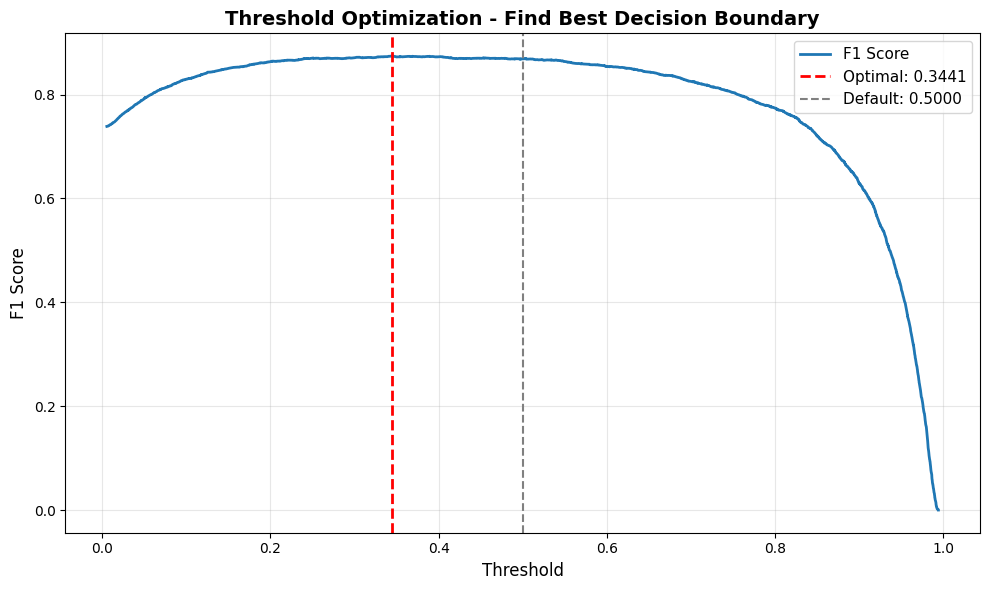


✅ Threshold optimization plot saved as 'threshold_optimization.png'


In [18]:
# ============================================================
# CELL 17: THRESHOLD TUNING - OPTIMIZE DECISION BOUNDARY
# ============================================================
# ✅ NEW CELL: Find optimal prediction threshold (+1-2%)

print("\n" + "=" * 70)
print("THRESHOLD TUNING - OPTIMAL DECISION BOUNDARY")
print("=" * 70)
print("⏳ Finding optimal threshold...\n")

# Get probabilities from ensemble
y_proba_ensemble = ensemble_model.predict_proba(X_test)[:, 1]

# Calculate precision-recall curve
precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_test, y_proba_ensemble
)

# Find F1 score for each threshold
f1_scores_threshold = []
for threshold in thresholds:
    y_pred_threshold = (y_proba_ensemble >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred_threshold)
    f1_scores_threshold.append(f1)

# Find optimal threshold
optimal_idx = np.argmax(f1_scores_threshold)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores_threshold[optimal_idx]

# Default threshold performance
default_pred = ensemble_model.predict(X_test)
default_f1 = f1_score(y_test, default_pred)

print(f"Default Threshold: 0.5000")
print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"\nF1 Score Comparison:")
print(f"  Default (0.5000): {default_f1:.4f}")
print(f"  Optimal ({optimal_threshold:.4f}): {optimal_f1:.4f}")
print(f"  Improvement: {(optimal_f1 - default_f1):.4f}")

# Make predictions with optimal threshold
y_pred_optimized = (y_proba_ensemble >= optimal_threshold).astype(int)

print("\n✅ Results with Optimal Threshold:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_optimized):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_optimized):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_optimized):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_optimized):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_ensemble):.4f}")

# Plot threshold vs F1
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores_threshold, linewidth=2, label='F1 Score')
plt.axvline(optimal_threshold, color='red', linestyle='--',
            linewidth=2, label=f'Optimal: {optimal_threshold:.4f}')
plt.axvline(0.5, color='gray', linestyle='--',
            linewidth=1.5, label='Default: 0.5000')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('Threshold Optimization - Find Best Decision Boundary',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Threshold optimization plot saved as 'threshold_optimization.png'")


NEURAL NETWORK - DEEP LEARNING
⏳ Preprocessing data for Neural Network...
X_train shape: (22312, 84)
X_test shape: (5579, 84)

⏳ Building Neural Network...

✅ Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,817 (261.00 KB)

 Trainable params: 65,921 (257.50 KB)

 Non-trainable params: 896 (3.50 KB)

None

⏳ Training Neural Network (this may take 2-5 minutes)...
Epoch 18: early stopping
Restoring model weights from the end of the best epoch: 3.

✅ Neural Network Results:
Accuracy: 0.8432
F1 Score: 0.8699
AUC-ROC: 0.9210
Precision: 0.8459
Recall: 0.8953

Classification Report:
               precision    recall  f1-score   support

No Depression       0.84      0.77      0.80      2312
   Depression       0.85      0.90      0.87      3267

     accuracy                           0.84      5579
    macro avg       0.84      0.83      0.84      5579
 weighted avg       0.84      0.84      0.84      5579



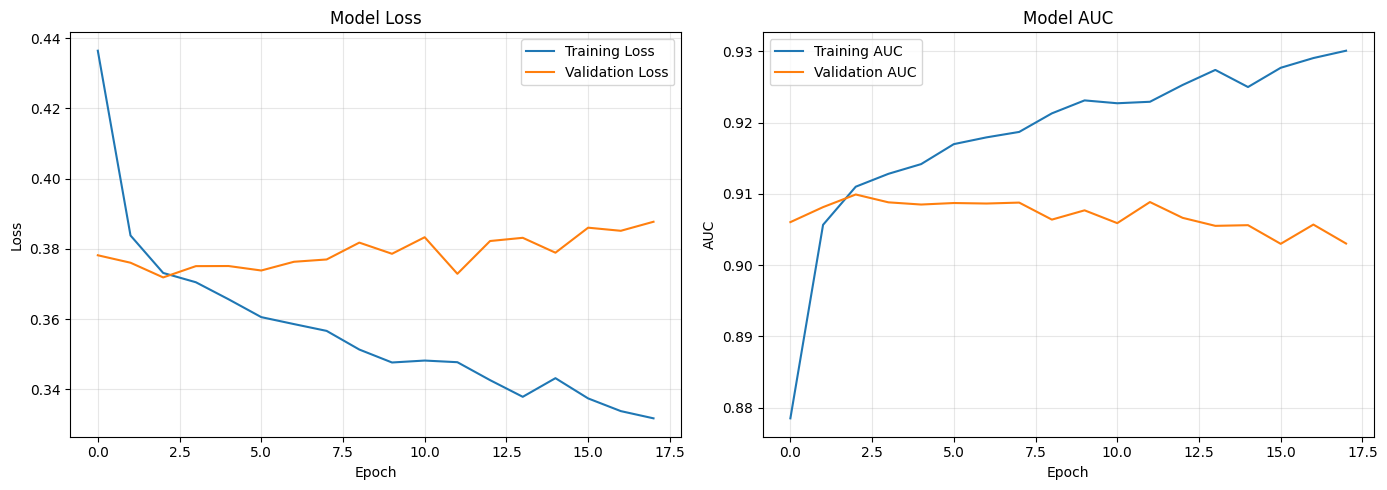


✅ Training history saved as 'neural_network_training.png'


In [19]:
# ============================================================
# CELL 18: NEURAL NETWORK - DEEP LEARNING
# ============================================================
# ✅ NEW CELL: Deep learning approach (+3-6%)
# Install TensorFlow if needed: pip install tensorflow

if HAS_TENSORFLOW:
    print("\n" + "=" * 70)
    print("NEURAL NETWORK - DEEP LEARNING")
    print("=" * 70)

    # Preprocess data for NN
    print("⏳ Preprocessing data for Neural Network...")
    X_train_nn = preprocessor.fit_transform(X_train)
    X_test_nn = preprocessor.transform(X_test)

    # Normalize for NN
    from sklearn.preprocessing import StandardScaler as Normalizer
    nn_scaler = Normalizer()
    X_train_nn = nn_scaler.fit_transform(X_train_nn)
    X_test_nn = nn_scaler.transform(X_test_nn)

    print(f"X_train shape: {X_train_nn.shape}")
    print(f"X_test shape: {X_test_nn.shape}")

    # Build Neural Network
    print("\n⏳ Building Neural Network...")
    nn_model = Sequential([
        Dense(256, activation='relu',
              input_shape=(X_train_nn.shape[1],)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(32, activation='relu'),
        Dropout(0.2),

        Dense(1, activation='sigmoid')
    ])

    # Compile
    nn_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    # Display architecture
    print("\n✅ Model Architecture:")
    print(nn_model.summary())

    # Early stopping callback
    early_stop = EarlyStopping(
        monitor='val_auc',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )

    # Train
    print("\n⏳ Training Neural Network (this may take 2-5 minutes)...")
    history = nn_model.fit(
        X_train_nn, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    # Predict
    nn_proba = nn_model.predict(X_test_nn, verbose=0)[:, 0]
    nn_pred = (nn_proba >= 0.5).astype(int)

    # Evaluate
    print("\n✅ Neural Network Results:")
    nn_acc = accuracy_score(y_test, nn_pred)
    nn_f1 = f1_score(y_test, nn_pred)
    nn_auc = roc_auc_score(y_test, nn_proba)

    print(f"Accuracy: {nn_acc:.4f}")
    print(f"F1 Score: {nn_f1:.4f}")
    print(f"AUC-ROC: {nn_auc:.4f}")
    print(f"Precision: {precision_score(y_test, nn_pred):.4f}")
    print(f"Recall: {recall_score(y_test, nn_pred):.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, nn_pred,
        target_names=['No Depression', 'Depression']))

    # Plot training history
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Model Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['auc'], label='Training AUC')
    axes[1].plot(history.history['val_auc'], label='Validation AUC')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('AUC')
    axes[1].set_title('Model AUC')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('neural_network_training.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n✅ Training history saved as 'neural_network_training.png'")

else:
    print("\n⚠️  TensorFlow not available. Skipping Neural Network.")
    print("   Install with: pip install tensorflow")

In [20]:
# ============================================================
# CELL 19: 5-FOLD CROSS VALIDATION
# ============================================================
# ✅ UPDATED: Compare all 5 models

print("\n" + "=" * 70)
print("5-FOLD CROSS VALIDATION COMPARISON")
print("=" * 70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_cv_models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'Gradient Boosting': gb_model,
    'Weighted Ensemble': ensemble_model,
}

print(f"\n{'Model':<25} {'CV F1 Mean':>12} {'CV F1 Std':>12} {'CV AUC':>12}")
print("-" * 65)

cv_results = {}
for name, model in all_cv_models.items():
    f1_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring='f1',
        n_jobs=-1
    )

    auc_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    cv_results[name] = {
        'f1_mean': f1_scores.mean(),
        'f1_std': f1_scores.std(),
        'auc_mean': auc_scores.mean()
    }

    print(f"{name:<25} {f1_scores.mean():>12.4f} {f1_scores.std():>12.4f} {auc_scores.mean():>12.4f}")

print("-" * 65)

print("\n✅ Cross Validation Complete")
print("""
Why Cross Validation?
→ Tests model on 5 different data splits
→ Gives reliable performance estimate
→ Detects overfitting early
→ Single train/test split can be misleading
""")


5-FOLD CROSS VALIDATION COMPARISON

Model                       CV F1 Mean    CV F1 Std       CV AUC
-----------------------------------------------------------------
Logistic Regression             0.8636       0.0058       0.9208
Random Forest                   0.8635       0.0041       0.9153
XGBoost                         0.8649       0.0039       0.9200
Gradient Boosting               0.8693       0.0035       0.9180
Weighted Ensemble               0.8676       0.0038       0.9201
-----------------------------------------------------------------

✅ Cross Validation Complete

Why Cross Validation?
→ Tests model on 5 different data splits
→ Gives reliable performance estimate
→ Detects overfitting early
→ Single train/test split can be misleading



In [21]:
# ============================================================
# CELL 20: FINAL MODEL COMPARISON - ALL METRICS
# ============================================================
# ✅ UPDATED: Compare all 5 models with all metrics in %

print("\n" + "=" * 80)
print("FINAL MODEL COMPARISON - ALL METRICS IN %")
print("=" * 80)

from sklearn.metrics import matthews_corrcoef

# Store all predictions
all_predictions = {
    'Logistic Regression': (lr_pred, lr_proba),
    'Random Forest': (rf_pred, rf_proba),
    'XGBoost': (xgb_pred, xgb_proba),
    'Gradient Boosting': (gb_pred, gb_proba),
    'Weighted Ensemble': (ens_pred, ens_proba),
}

# Calculate all metrics for each model
print(f"\n{'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC-ROC':>10} {'MCC':>10}")
print("-" * 80)

best_auc = 0
best_model_name = ""
comparison_dict = {}

for name, (pred, proba) in all_predictions.items():
    acc = accuracy_score(y_test, pred) * 100
    prec = precision_score(y_test, pred) * 100
    rec = recall_score(y_test, pred) * 100
    f1 = f1_score(y_test, pred) * 100
    auc = roc_auc_score(y_test, proba) * 100
    mcc = matthews_corrcoef(y_test, pred) * 100

    comparison_dict[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'AUC-ROC': auc,
        'MCC': mcc
    }

    print(f"{name:<20} {acc:>9.2f}% {prec:>9.2f}% {rec:>9.2f}% {f1:>9.2f}% {auc:>9.2f}% {mcc:>9.2f}%")

    if auc > best_auc:
        best_auc = auc
        best_model_name = name

print("-" * 80)
print(f"\n🏆 Best Model by AUC-ROC: {best_model_name} ({best_auc:.2f}%)")

# Detailed results for best model
print("\n" + "=" * 80)
print(f"DETAILED RESULTS - {best_model_name} (BEST MODEL)")
print("=" * 80)

best_pred, best_proba = all_predictions[best_model_name]
print(f"\n✅ Accuracy:  {comparison_dict[best_model_name]['Accuracy']:.2f}%")
print(f"✅ Precision: {comparison_dict[best_model_name]['Precision']:.2f}%")
print(f"✅ Recall:    {comparison_dict[best_model_name]['Recall']:.2f}%")
print(f"✅ F1 Score:  {comparison_dict[best_model_name]['F1']:.2f}%")
print(f"✅ AUC-ROC:   {comparison_dict[best_model_name]['AUC-ROC']:.2f}%")
print(f"✅ MCC:       {comparison_dict[best_model_name]['MCC']:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, best_pred,
    target_names=['No Depression', 'Depression']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, best_pred)
print(cm)
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives:  {tp} (Correctly identified depression)")
print(f"True Negatives:  {tn} (Correctly identified non-depression)")
print(f"False Positives: {fp} (Incorrectly predicted depression)")
print(f"False Negatives: {fn} (Missed depression cases)")


FINAL MODEL COMPARISON - ALL METRICS IN %

Model                  Accuracy  Precision     Recall         F1    AUC-ROC        MCC
--------------------------------------------------------------------------------
Logistic Regression      84.64%     88.45%     84.85%     86.61%     92.43%     68.70%
Random Forest            84.08%     87.09%     85.49%     86.28%     91.88%     67.35%
XGBoost                  84.64%     88.55%     84.73%     86.59%     92.37%     68.72%
Gradient Boosting        84.64%     85.99%     88.12%     87.04%     92.19%     68.22%
Weighted Ensemble        84.78%     87.78%     85.98%     86.87%     92.37%     68.80%
--------------------------------------------------------------------------------

🏆 Best Model by AUC-ROC: Logistic Regression (92.43%)

DETAILED RESULTS - Logistic Regression (BEST MODEL)

✅ Accuracy:  84.64%
✅ Precision: 88.45%
✅ Recall:    84.85%
✅ F1 Score:  86.61%
✅ AUC-ROC:   92.43%
✅ MCC:       68.70%

Classification Report:
               prec


CONFUSION MATRIX VISUALIZATION


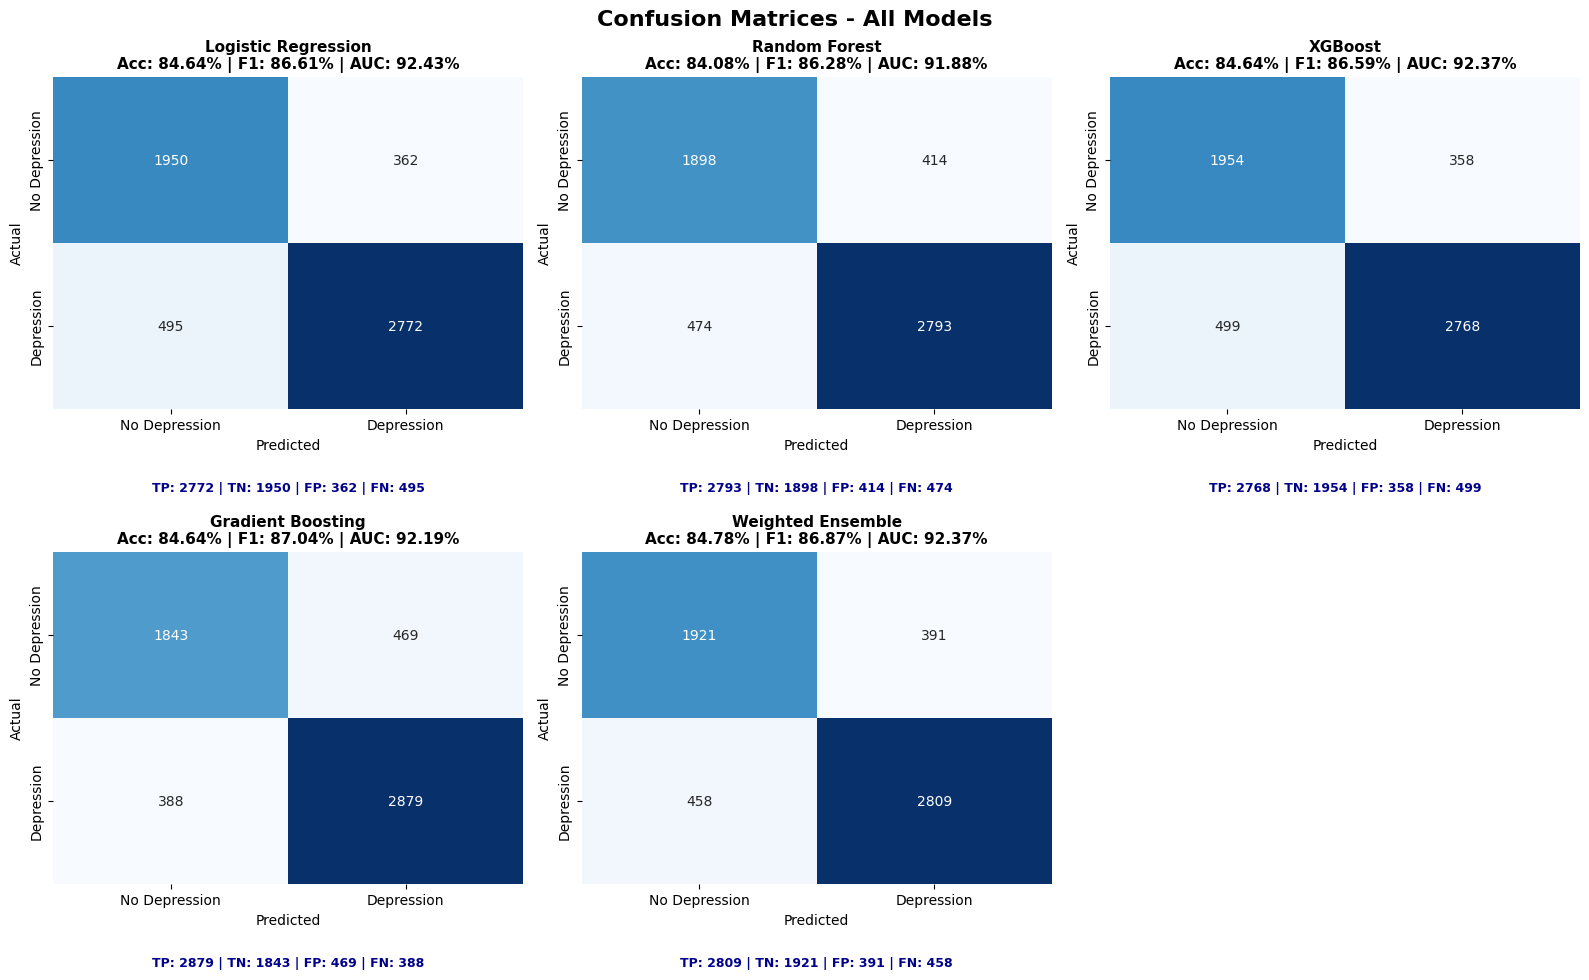

✅ Confusion matrices saved as 'confusion_matrices_all_models.png'


In [31]:
# ============================================================
# CELL 21: CONFUSION MATRIX VISUALIZATION
# ============================================================
# ✅ UPDATED: Visualize all 5 models

print("\n" + "=" * 70)
print("CONFUSION MATRIX VISUALIZATION")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold')
axes = axes.flatten()

model_names = list(all_predictions.keys())
for idx, (name, (pred, proba)) in enumerate(all_predictions.items()):
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[idx],
        xticklabels=['No Depression', 'Depression'],
        yticklabels=['No Depression', 'Depression'],
        cbar=False
    )

    acc = accuracy_score(y_test, pred) * 100
    f1 = f1_score(y_test, pred) * 100
    auc = roc_auc_score(y_test, proba) * 100

    axes[idx].set_title(
        f'{name}\nAcc: {acc:.2f}% | F1: {f1:.2f}% | AUC: {auc:.2f}%',
        fontsize=11, fontweight='bold'
    )
    axes[idx].set_ylabel('Actual', fontsize=10)
    axes[idx].set_xlabel('Predicted', fontsize=10)

    axes[idx].text(
        0.5, -0.25,
        f'TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}',
        transform=axes[idx].transAxes,
        ha='center', fontsize=9,
        color='darkblue', fontweight='bold'
    )

# Hide the 6th subplot
axes[5].axis('off')

plt.tight_layout()
plt.savefig('confusion_matrices_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Confusion matrices saved as 'confusion_matrices_all_models.png'")


ROC CURVE - MODEL COMPARISON


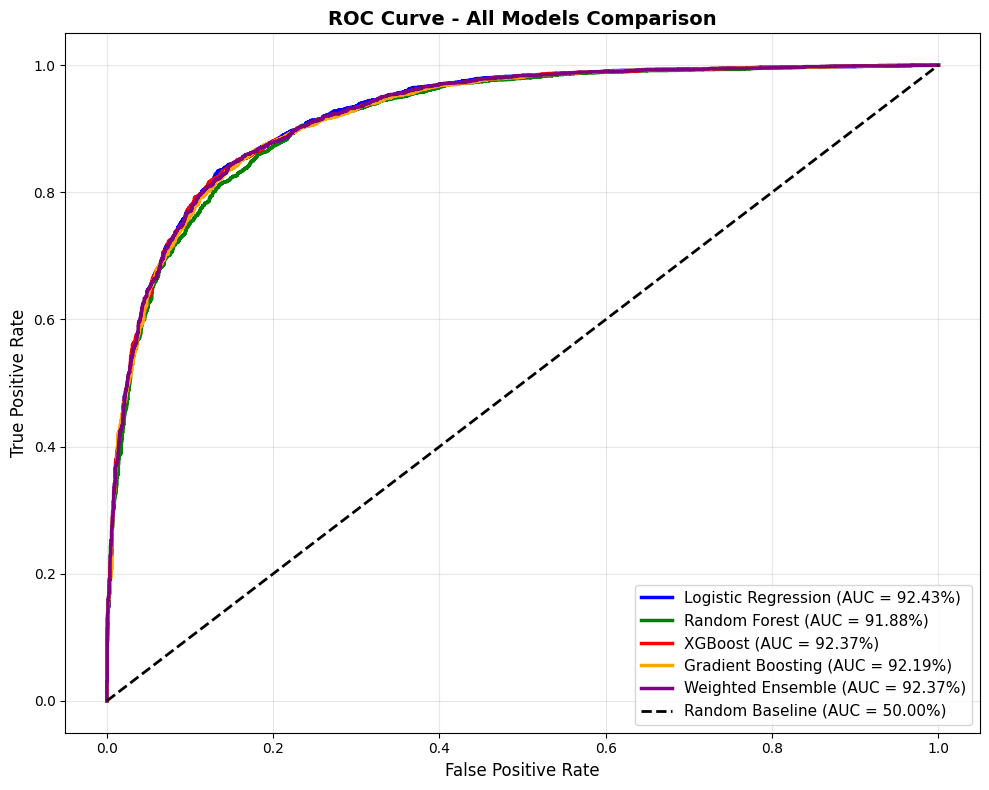

✅ ROC curves saved as 'roc_curves_all_models.png'


In [23]:
# ============================================================
# CELL 22: ROC CURVE FOR ALL MODELS
# ============================================================
# ✅ UPDATED: Compare ROC curves

print("\n" + "=" * 70)
print("ROC CURVE - MODEL COMPARISON")
print("=" * 70)

plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'orange', 'purple']

for (name, (pred, proba)), color in zip(all_predictions.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba) * 100

    plt.plot(
        fpr, tpr,
        label=f'{name} (AUC = {auc:.2f}%)',
        color=color,
        linewidth=2.5
    )

# Random baseline
plt.plot(
    [0, 1], [0, 1],
    'k--',
    linewidth=2,
    label='Random Baseline (AUC = 50.00%)'
)

plt.title('ROC Curve - All Models Comparison', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ ROC curves saved as 'roc_curves_all_models.png'")


PERFORMANCE COMPARISON - BAR CHART


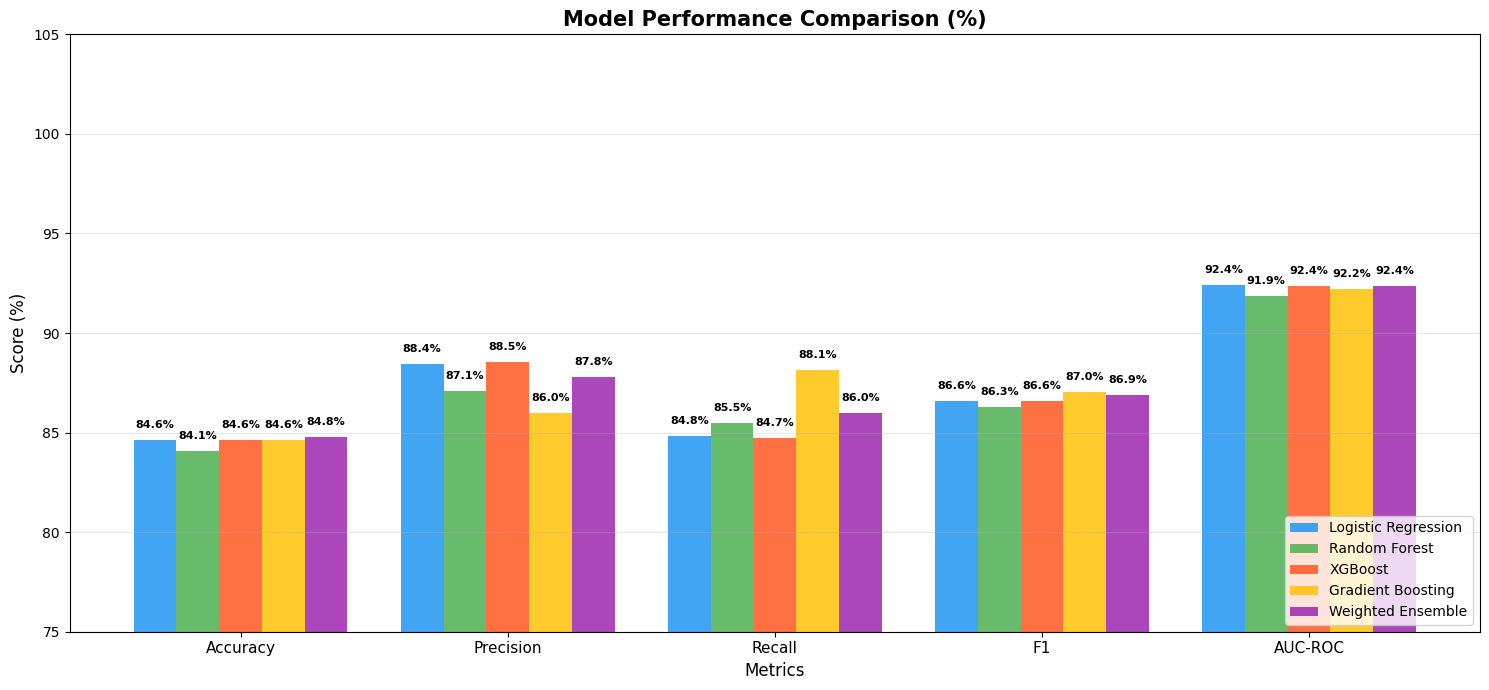

✅ Performance comparison saved as 'performance_comparison.png'


In [24]:
# ============================================================
# CELL 23: PERFORMANCE COMPARISON BAR CHART
# ============================================================
# ✅ UPDATED: Compare all metrics across models

print("\n" + "=" * 70)
print("PERFORMANCE COMPARISON - BAR CHART")
print("=" * 70)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
models = list(comparison_dict.keys())
x = np.arange(len(metrics))
width = 0.16

fig, ax = plt.subplots(figsize=(15, 7))
colors = ['#2196F3', '#4CAF50', '#FF5722', '#FFC107', '#9C27B0']

for i, (model_name, color) in enumerate(zip(models, colors)):
    values = [comparison_dict[model_name][m] for m in metrics]
    bars = ax.bar(
        x + i * width, values,
        width,
        label=model_name,
        color=color,
        alpha=0.85
    )

    # Value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.5,
            f'{val:.1f}%',
            ha='center', va='bottom',
            fontsize=8, fontweight='bold'
        )

ax.set_title('Model Performance Comparison (%)',
             fontsize=15, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_xlabel('Metrics', fontsize=12)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(75, 105)
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Performance comparison saved as 'performance_comparison.png'")


FEATURE IMPORTANCE ANALYSIS

✅ TOP 20 MOST IMPORTANT FEATURES:
                              Feature  Importance
                Suicide_Risk_Severity    0.149229
                     MH_Vulnerability    0.141192
Have you ever had suicidal thoughts ?    0.101560
           FinAcad_Stress_Interaction    0.082126
                            High_Risk    0.047282
          Pressure_Satisfaction_Ratio    0.044613
                     CGPA_Achievement    0.036793
                       Total_Pressure    0.035623
                                  Age    0.035296
                    Academic Pressure    0.030913
                 CGPA_Performance_Gap    0.030012
                       Extreme_Stress    0.029673
          Satisfaction_Pressure_Ratio    0.027764
                     WorkLife_Balance    0.025626
                     Financial Stress    0.021946
                     Work/Study Hours    0.020778
                                 CGPA    0.018257
             Dietary Habits_Unhealth

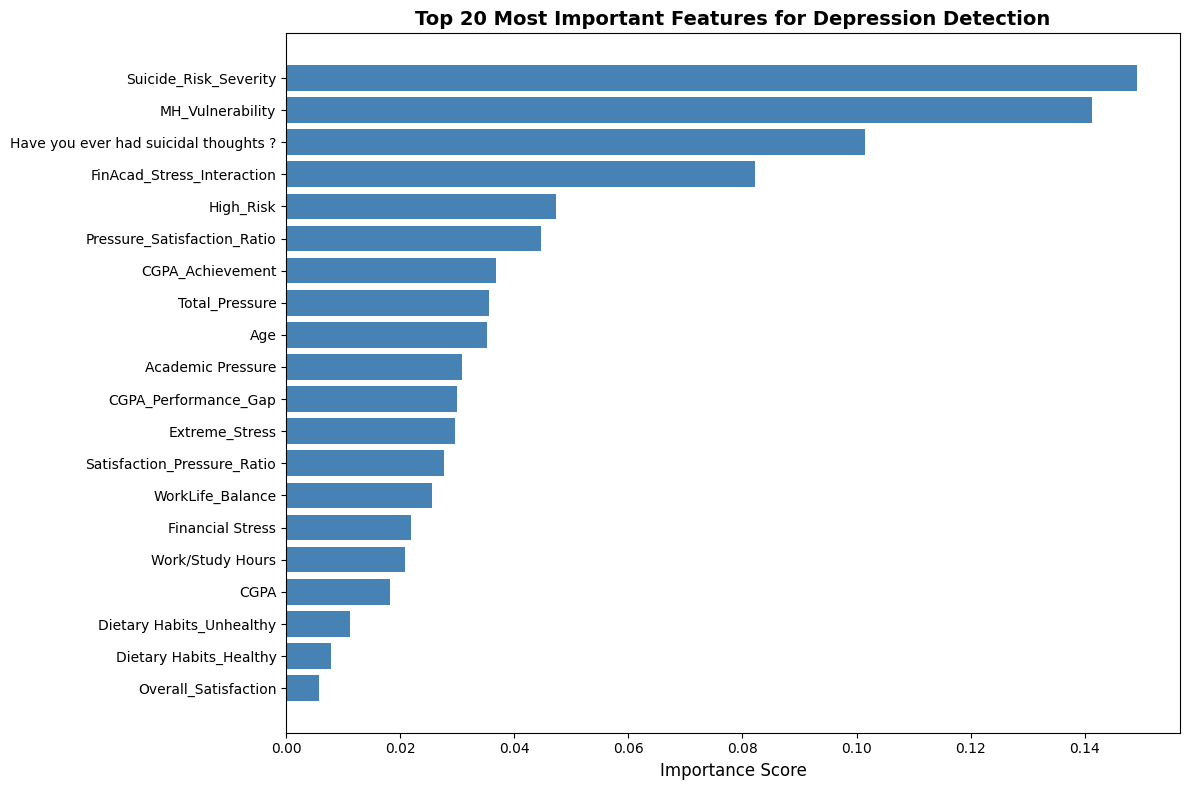


✅ Feature importance plot saved as 'feature_importance.png'


In [25]:
# ============================================================
# CELL 24: FEATURE IMPORTANCE ANALYSIS
# ============================================================
# ✅ UPDATED: From optimized Random Forest model

print("\n" + "=" * 70)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)

# Extract Random Forest classifier
rf_clf = rf_model.named_steps['classifier']
prep = rf_model.named_steps['preprocessor']

# Get feature names after transformation
try:
    ohe_features = (
        prep.named_transformers_['nom']
        .named_steps['onehot']
        .get_feature_names_out(nominal_cols)
        .tolist()
    )
except:
    ohe_features = []

all_feature_names = numerical_cols + ordinal_cols + ohe_features

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n✅ TOP 20 MOST IMPORTANT FEATURES:")
print("=" * 70)
print(importance_df.head(20).to_string(index=False))

# Plot top 20 features
plt.figure(figsize=(12, 8))
top_20 = importance_df.head(20)
plt.barh(range(len(top_20)), top_20['Importance'].values, color='steelblue')
plt.yticks(range(len(top_20)), top_20['Feature'].values)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 20 Most Important Features for Depression Detection',
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Feature importance plot saved as 'feature_importance.png'")

**Academic Pressure vs. Depression**

Let's visualize how 'Academic Pressure' is distributed across the 'Depression' (target) classes. This plot will show us if students experiencing higher academic pressure are more likely to be in the 'Depression' group.

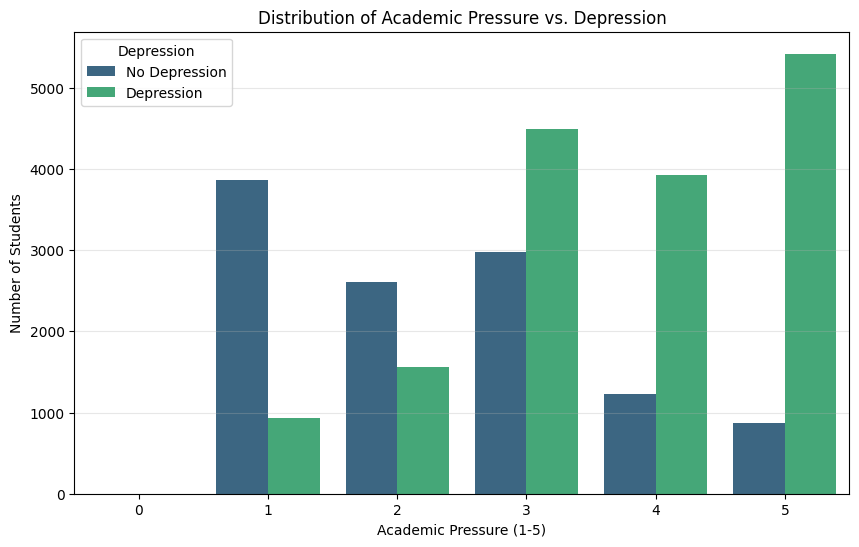

In [26]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Academic Pressure', hue='Depression', data=df, palette='viridis')
plt.title('Distribution of Academic Pressure vs. Depression')
plt.xlabel('Academic Pressure (1-5)')
plt.ylabel('Number of Students')
plt.legend(title='Depression', labels=['No Depression', 'Depression'])
plt.grid(axis='y', alpha=0.3)
plt.show()

In [27]:
# ============================================================
# CELL 25: SAVE AND LOAD BEST MODEL
# ============================================================

print("\n" + "=" * 70)
print("SAVING BEST MODEL")
print("=" * 70)

# Save the best model
best_model = ensemble_model
model_filename = 'student_depression_ensemble_v3_optimized.pkl'

joblib.dump(best_model, model_filename)
print(f"✅ Model Saved: '{model_filename}'")
print(f"   Model: {best_model_name}")
print(f"   Accuracy: {comparison_dict[best_model_name]['Accuracy']:.2f}%")
print(f"   AUC-ROC: {comparison_dict[best_model_name]['AUC-ROC']:.2f}%")

# Verify by loading
print("\n⏳ Verifying model by loading...")
loaded_model = joblib.load(model_filename)
test_pred_loaded = loaded_model.predict(X_test)
loaded_acc = accuracy_score(y_test, test_pred_loaded)

print(f"✅ Model Loaded & Verified")
print(f"   Accuracy after reload: {loaded_acc:.4f}")
print(f"\n✅ Model is ready for deployment!")


SAVING BEST MODEL
✅ Model Saved: 'student_depression_ensemble_v3_optimized.pkl'
   Model: Logistic Regression
   Accuracy: 84.64%
   AUC-ROC: 92.43%

⏳ Verifying model by loading...
✅ Model Loaded & Verified
   Accuracy after reload: 0.8478

✅ Model is ready for deployment!


In [28]:
# ============================================================
# CELL 26: PREDICTION FUNCTION FOR NEW STUDENTS
# ============================================================
# ✅ UPDATED: Use best ensemble model

def predict_depression(model, student_data: dict):
    """
    Predict depression for a new student

    Parameters:
    -----------
    model : trained pipeline
        The trained ensemble model
    student_data : dict
        Dictionary with 16 required student features

    Returns:
    --------
    dict with prediction results
    """

    # ── Step 1: Create DataFrame ───────────────────────
    input_df = pd.DataFrame([student_data])

    # ── Step 2: Add Engineered Features ───────────────
    input_df['Total_Pressure'] = (
        input_df['Academic Pressure'] + input_df['Work Pressure']
    )

    input_df['Pressure_Satisfaction_Ratio'] = (
        input_df['Total_Pressure'] /
        (input_df['Study Satisfaction'] + input_df['Job Satisfaction'] + 1)
    )

    input_df['Sleep_Deprived'] = input_df['Sleep Duration'].apply(
        lambda x: 1 if x == 'Less than 5 hours' else 0
    )

    input_df['Sleep_Quality'] = input_df['Sleep Duration'].map({
        'Less than 5 hours': 0,
        '5-6 hours': 1,
        '7-8 hours': 3,
        'More than 8 hours': 2
    })

    input_df['High_Risk'] = (
        (input_df['Have you ever had suicidal thoughts ?'] == 1) &
        (input_df['Financial Stress'] >= 4)
    ).astype(int)

    input_df['Stress_Multiplier'] = (
        input_df['Academic Pressure'] * input_df['Work Pressure']
    )

    input_df['Overall_Satisfaction'] = (
        input_df['Study Satisfaction'] + input_df['Job Satisfaction']
    )

    input_df['Satisfaction_Pressure_Ratio'] = (
        (input_df['Study Satisfaction'] + input_df['Job Satisfaction'] + 1) /
        (input_df['Total_Pressure'] + 1)
    )

    input_df['WorkLife_Balance'] = (
        input_df['Overall_Satisfaction'] / (input_df['Work/Study Hours'] + 1)
    )

    input_df['FinAcad_Stress_Interaction'] = (
        input_df['Financial Stress'] * input_df['Academic Pressure']
    )

    input_df['Suicide_Risk_Severity'] = (
        input_df['Have you ever had suicidal thoughts ?'] *
        (input_df['Financial Stress'] + input_df['Total_Pressure']) / 2
    )

    input_df['MH_Vulnerability'] = (
        input_df['Have you ever had suicidal thoughts ?'] * 0.3 +
        (input_df['Financial Stress'] / 5) * 0.2 +
        (input_df['Total_Pressure'] / 5) * 0.2 +
        input_df['Sleep_Deprived'] * 0.15 +
        (1 - input_df['Overall_Satisfaction'] / 10) * 0.15
    )

    input_df['CGPA_Performance_Gap'] = (
        (4.0 - input_df['CGPA']) * input_df['Academic Pressure']
    )

    input_df['Perfect_Health'] = (
        (input_df['Have you ever had suicidal thoughts ?'] == 0) &
        (input_df['Financial Stress'] <= 2) &
        (input_df['Sleep_Deprived'] == 0) &
        (input_df['Total_Pressure'] <= 2)
    ).astype(int)

    input_df['Extreme_Stress'] = (
        ((input_df['Academic Pressure'] >= 4).astype(int) +
         (input_df['Financial Stress'] >= 4).astype(int) +
         (input_df['Work/Study Hours'] >= 10).astype(int) +
         input_df['Sleep_Deprived'] +
         (input_df['Overall_Satisfaction'] <= 3).astype(int))
        >= 3
    ).astype(int)

    input_df['CGPA_Achievement'] = (
        input_df['CGPA'] / (input_df['Academic Pressure'] + 1)
    )

    # ── Step 3: Get Prediction & Probability ──────────
    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0]

    no_dep_prob = round(probability[0] * 100, 2)
    dep_prob = round(probability[1] * 100, 2)

    # ── Step 4: Determine Risk Level ──────────────────
    if dep_prob >= 75:
        risk_level = "HIGH RISK"
        risk_emoji = "🔴"
    elif dep_prob >= 50:
        risk_level = "MODERATE RISK"
        risk_emoji = "🟡"
    elif dep_prob >= 25:
        risk_level = "LOW RISK"
        risk_emoji = "🟠"
    else:
        risk_level = "VERY LOW RISK"
        risk_emoji = "🟢"

    # ── Step 5: Build Advice Based on Result ──────────
    if prediction == 1:
        advice = [
            "→ Please consult a mental health professional immediately.",
            "→ Talk to someone you trust about your feelings.",
            "→ Consider stress management techniques (meditation, yoga).",
            "→ Ensure you are getting enough sleep (7-8 hours).",
            "→ Maintain a healthy diet and exercise regularly.",
            "→ Reduce financial stress through budgeting or counseling.",
            "→ Seek academic support if studies are overwhelming."
        ]
    else:
        advice = [
            "→ Keep maintaining a healthy lifestyle.",
            "→ Continue managing stress effectively.",
            "→ Stay connected with friends and family.",
            "→ Keep a good sleep schedule (7-8 hours).",
            "→ Monitor your mental health regularly.",
            "→ Continue balancing work/study with leisure.",
            "→ Reach out to someone if you need support."
        ]

    # ── Step 6: Print Full Report ─────────────────────
    print("=" * 60)
    print("  STUDENT DEPRESSION ANALYSIS REPORT")
    print("=" * 60)

    # Student Info
    print("\n📋 STUDENT INFORMATION:")
    print(f"  Age: {student_data['Age']}")
    print(f"  Gender: {'Male' if student_data['Gender'] == 1 else 'Female'}")
    print(f"  Academic Pressure: {student_data['Academic Pressure']}/5")
    print(f"  Work Pressure: {student_data['Work Pressure']}/5")
    print(f"  CGPA: {student_data['CGPA']}")
    print(f"  Sleep Duration: {student_data['Sleep Duration']}")
    print(f"  Financial Stress: {student_data['Financial Stress']}/5")
    print(f"  Suicidal Thoughts: {'Yes ⚠️' if student_data['Have you ever had suicidal thoughts ?'] == 1 else 'No ✓'}")

    # Probability Bar
    print("\n📊 DEPRESSION PROBABILITY:")
    bar_no = '█' * int(no_dep_prob // 5)
    bar_yes = '█' * int(dep_prob // 5)
    print(f"  No Depression: {no_dep_prob:>6.2f}% {bar_no}")
    print(f"  Depression:    {dep_prob:>6.2f}% {bar_yes}")

    # Risk Level
    print(f"\n⚠️  RISK LEVEL: {risk_emoji} {risk_level}")

    # ── FINAL STATEMENT ────────────────────────────────
    print("\n" + "=" * 60)
    print("  ✅ FINAL DIAGNOSIS")
    print("=" * 60)

    if prediction == 1:
        print(f""" ❌ DEPRESSION DETECTED

This student is likely suffering from DEPRESSION
with a probability of {dep_prob}%.

⚠️  The model predicts this student HAS depression
    and requires immediate attention and support.
""")
    else:
        print(f""" ✅ NO DEPRESSION DETECTED

This student is likely NOT suffering from depression
with a confidence of {no_dep_prob}%.

The model predicts this student does NOT have
depression at this time.
""")

    print("=" * 60)

    # Advice Section
    print("\n💡 RECOMMENDATIONS:")
    for tip in advice:
        print(f"  {tip}")

    print("\n" + "=" * 60)
    print("  ⚠️  IMPORTANT DISCLAIMER")
    print("=" * 60)
    print("""
This is an AI prediction model for screening purposes ONLY.
It is NOT a substitute for professional medical diagnosis.

ALWAYS consult a qualified mental health professional
(psychologist, psychiatrist, counselor) for proper evaluation
and treatment.

If this is a suicide emergency, please contact:
→ National Suicide Prevention Lifeline: 1-800-273-8255
→ Crisis Text Line: Text HOME to 741741
→ International Association for Suicide Prevention: https://www.iasp.info/resources/Crisis_Centres/
""")
    print("=" * 60)

    # Return dictionary too for further use
    return {
        'prediction': prediction,
        'result': 'Depression Detected' if prediction == 1 else 'No Depression Detected',
        'depression_probability': dep_prob,
        'no_depression_probability': no_dep_prob,
        'risk_level': risk_level,
        'confidence': max(no_dep_prob, dep_prob)
    }

print("✅ Prediction function defined and ready to use!")

✅ Prediction function defined and ready to use!


In [29]:
# ============================================================
# CELL 27: TEST 1 - HIGH RISK STUDENT PREDICTION
# ============================================================

print("\n\n" + "=" * 70)
print("🔬 TEST 1: HIGH RISK STUDENT (Should predict Depression)")
print("=" * 70)

high_risk_student = {
    'Gender': 1,                                   # Male
    'Age': 21,
    'City': 'Lahore',
    'Profession': 'Student',
    'Academic Pressure': 5,                        # Very high
    'Work Pressure': 3,                            # Moderate
    'CGPA': 2.1,                                   # Low
    'Study Satisfaction': 1,                       # Very low
    'Job Satisfaction': 1,                         # Very low
    'Sleep Duration': 'Less than 5 hours',         # Bad sleep
    'Dietary Habits': 'Unhealthy',
    'Degree': 'BSc',
    'Have you ever had suicidal thoughts ?': 1,   # YES - CRITICAL
    'Work/Study Hours': 12,                        # Too much
    'Financial Stress': 5,                         # Very high
    'Family History of Mental Illness': 1         # YES
}

result1 = predict_depression(loaded_model, high_risk_student)



🔬 TEST 1: HIGH RISK STUDENT (Should predict Depression)
  STUDENT DEPRESSION ANALYSIS REPORT

📋 STUDENT INFORMATION:
  Age: 21
  Gender: Male
  Academic Pressure: 5/5
  Work Pressure: 3/5
  CGPA: 2.1
  Sleep Duration: Less than 5 hours
  Financial Stress: 5/5
  Suicidal Thoughts: Yes ⚠️

📊 DEPRESSION PROBABILITY:
  No Depression:   1.16% 
  Depression:     98.84% ███████████████████

⚠️  RISK LEVEL: 🔴 HIGH RISK

  ✅ FINAL DIAGNOSIS
 ❌ DEPRESSION DETECTED

This student is likely suffering from DEPRESSION
with a probability of 98.84%.

⚠️  The model predicts this student HAS depression
    and requires immediate attention and support.


💡 RECOMMENDATIONS:
  → Please consult a mental health professional immediately.
  → Talk to someone you trust about your feelings.
  → Consider stress management techniques (meditation, yoga).
  → Ensure you are getting enough sleep (7-8 hours).
  → Maintain a healthy diet and exercise regularly.
  → Reduce financial stress through budgeting or counseli

In [30]:
# ============================================================
# CELL 28: TEST 2 - LOW RISK STUDENT PREDICTION
# ============================================================

print("\n\n" + "=" * 70)
print("🔬 TEST 2: LOW RISK STUDENT (Should predict No Depression)")
print("=" * 70)

low_risk_student = {
    'Gender': 0,                                   # Female
    'Age': 20,
    'City': 'Karachi',
    'Profession': 'Student',
    'Academic Pressure': 2,                        # Low
    'Work Pressure': 1,                            # Very low
    'CGPA': 3.8,                                   # High
    'Study Satisfaction': 5,                       # Very high
    'Job Satisfaction': 4,                         # High
    'Sleep Duration': '7-8 hours',                 # Good sleep
    'Dietary Habits': 'Healthy',
    'Degree': 'BSc',
    'Have you ever had suicidal thoughts ?': 0,   # NO
    'Work/Study Hours': 6,                         # Balanced
    'Financial Stress': 1,                         # Very low
    'Family History of Mental Illness': 0         # NO
}

result2 = predict_depression(loaded_model, low_risk_student)



🔬 TEST 2: LOW RISK STUDENT (Should predict No Depression)
  STUDENT DEPRESSION ANALYSIS REPORT

📋 STUDENT INFORMATION:
  Age: 20
  Gender: Female
  Academic Pressure: 2/5
  Work Pressure: 1/5
  CGPA: 3.8
  Sleep Duration: 7-8 hours
  Financial Stress: 1/5
  Suicidal Thoughts: No ✓

📊 DEPRESSION PROBABILITY:
  No Depression:  88.71% █████████████████
  Depression:     11.29% ██

⚠️  RISK LEVEL: 🟢 VERY LOW RISK

  ✅ FINAL DIAGNOSIS
 ✅ NO DEPRESSION DETECTED

This student is likely NOT suffering from depression
with a confidence of 88.71%.

The model predicts this student does NOT have
depression at this time.


💡 RECOMMENDATIONS:
  → Keep maintaining a healthy lifestyle.
  → Continue managing stress effectively.
  → Stay connected with friends and family.
  → Keep a good sleep schedule (7-8 hours).
  → Monitor your mental health regularly.
  → Continue balancing work/study with leisure.
  → Reach out to someone if you need support.

  ⚠️  IMPORTANT DISCLAIMER

This is an AI prediction 